# SWEC-ETHZ short-term: LOSO model building

This notebook is the **next step after preprocessing and feature selection**.

It focuses on **model training and evaluation** using **leave-one-subject-out (LOSO)** validation.

In LOSO:
- we hold out **one participant ID** as the test subject,
- we train on all remaining participants,
- then we repeat this so that every participant becomes the test subject once.

This is a strong test of **subject generalization**.


## What this notebook does

1. Loads the **window-level feature table** created during preprocessing  
2. Shows basic information about the labels and class balance  
3. Optionally loads **fold-specific selected features** from the feature-selection notebook  
4. Builds one classifier at a time using **LOSO**
5. Computes:
   - predictions
   - class probabilities
   - confusion matrices
   - beginner-friendly performance metrics
6. Saves the outputs for later steps such as:
   - HMM postprocessing
   - explainability
   - error analysis

The default task is:

- **binary classification**
- `seizure` vs `non_seizure`


## Why we scale features

Many EEG features have very different numeric ranges.

For example:
- mean amplitude,
- maximum value,
- line length,
- band power

may all live on different scales.

That matters especially for:
- Logistic Regression
- SVM

So in each LOSO fold we standardize features using the training subjects only.

$$
z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}
$$

In plain words:

`z = (x - training mean) / training standard deviation`

This prevents **data leakage** because the held-out subject is never used to compute the scaling values.


## Why we save probabilities

We save both:
- the predicted class
- the predicted probability of seizure

The probabilities are useful because the next post-processing notebook can use them in:
- **HMM smoothing**
- threshold tuning
- confidence analysis

So even if the main prediction is binary, we keep the full probability information.


In [1]:
# Core imports
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import LeaveOneGroupOut

# Optional XGBoost support
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False
    XGBClassifier = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


In [15]:
# ---------------------------
# Input paths
# ---------------------------
FEATURES_DIR = Path("../data/synthetic/simulated_swec_features_package/derived_features_swec_short")
FEATURES_PARQUET = FEATURES_DIR / "all_window_features.parquet"
FEATURES_CSV = FEATURES_DIR / "all_window_features.csv"
MANIFEST_CSV = FEATURES_DIR / "recording_manifest.csv"
PARTICIPANT_SUMMARY_CSV = FEATURES_DIR / "participant_summary.csv"

# Feature-selection outputs (optional)
FS_OUTPUT_DIR = Path("../examples/derived_ml_swec_short/feature_selection__rfe__mode-metric_stop__score-balanced_accuracy__base-logreg__auto-min-5__tol-0.001__step-1")
FS_RUN_NAME = ""
# Example:
# FS_RUN_NAME = "feature_selection__filter_f_classif__score-balanced_accuracy__base-logreg__k-20"

# ---------------------------
# Model output path
# ---------------------------
OUTPUT_DIR = Path("derived_ml_swec_short")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Core columns
# ---------------------------
TARGET_COLUMN = "target"
POSITIVE_LABEL = "seizure"
NEGATIVE_LABEL = "non_seizure"
SUBJECT_COLUMN = "subject_id"
RECORDING_COLUMN = "recording_id"
WINDOW_INDEX_COLUMN = "window_idx"

# ---------------------------
# Task setup
# ---------------------------
SUBJECT_IDS = None          # Set to a list such as ["ID1", "ID2"] for a smoke test
USE_SELECTED_FEATURES = True

# ---------------------------
# Model choice
# Choose one:
#   "logreg"
#   "linear_svm"
#   "rbf_svm"
#   "random_forest"
#   "gradient_boosting"
#   "xgboost"
# ---------------------------
MODEL_NAME = "logreg"

# ---------------------------
# General model settings
# ---------------------------
RANDOM_STATE = 42

# Logistic Regression
LOGREG_C = 1.0

# SVM
SVM_C = 1.0
SVM_GAMMA = "scale"

# Random Forest
RF_N_ESTIMATORS = 300
RF_MAX_DEPTH = None
RF_MIN_SAMPLES_LEAF = 1

# Gradient Boosting
GB_N_ESTIMATORS = 150
GB_LEARNING_RATE = 0.05
GB_MAX_DEPTH = 3

# XGBoost
XGB_N_ESTIMATORS = 200
XGB_MAX_DEPTH = 4
XGB_LEARNING_RATE = 0.05
XGB_SUBSAMPLE = 0.9
XGB_COLSAMPLE_BYTREE = 0.9

# ---------------------------
# Probability threshold
# ---------------------------
POSITIVE_THRESHOLD = 0.50


## Load the feature table

We first load the saved table from preprocessing.

Each row should represent:
- one EEG window
- one participant
- one recording
- one label
- many feature columns


In [5]:
# Load the main feature table
if FEATURES_PARQUET.exists():
    all_df = pd.read_parquet(FEATURES_PARQUET)
elif FEATURES_CSV.exists():
    all_df = pd.read_csv(FEATURES_CSV)
else:
    raise FileNotFoundError(
        f"Could not find {FEATURES_PARQUET} or {FEATURES_CSV}. "
        "Run the preprocessing notebook first."
    )

manifest_df = pd.read_csv(MANIFEST_CSV) if MANIFEST_CSV.exists() else None
participant_summary_df = pd.read_csv(PARTICIPANT_SUMMARY_CSV) if PARTICIPANT_SUMMARY_CSV.exists() else None

print("Loaded feature table with shape:", all_df.shape)
all_df.head()


Loaded feature table with shape: (240, 114)


,subject_id,recording_id,fileName,window_idx,window_start_s,window_end_s,target,label,is_seizure_window,crop_start_s,crop_end_s,crop_duration_s,fs,n_channels,line_length__ch01,line_length__ch02,line_length__ch03,line_length__ch04,line_length__ch05,line_length__ch06,line_length__ch07,line_length__ch08,line_length__ch09,line_length__ch10,line_length__ch11,line_length__ch12,line_length__ch13,line_length__ch14,line_length__ch15,line_length__ch16,line_length__ch17,line_length__ch18,line_length__ch19,line_length__ch20,amp_var__ch01,amp_var__ch02,amp_var__ch03,amp_var__ch04,amp_var__ch05,amp_var__ch06,amp_var__ch07,amp_var__ch08,amp_var__ch09,amp_var__ch10,amp_var__ch11,amp_var__ch12,amp_var__ch13,amp_var__ch14,amp_var__ch15,amp_var__ch16,amp_var__ch17,amp_var__ch18,amp_var__ch19,amp_var__ch20,mean__ch01,mean__ch02,mean__ch03,mean__ch04,mean__ch05,mean__ch06,mean__ch07,mean__ch08,mean__ch09,mean__ch10,mean__ch11,mean__ch12,mean__ch13,mean__ch14,mean__ch15,mean__ch16,mean__ch17,mean__ch18,mean__ch19,mean__ch20,max__ch01,max__ch02,max__ch03,max__ch04,max__ch05,max__ch06,max__ch07,max__ch08,max__ch09,max__ch10,max__ch11,max__ch12,max__ch13,max__ch14,max__ch15,max__ch16,max__ch17,max__ch18,max__ch19,max__ch20,min__ch01,min__ch02,min__ch03,min__ch04,min__ch05,min__ch06,min__ch07,min__ch08,min__ch09,min__ch10,min__ch11,min__ch12,min__ch13,min__ch14,min__ch15,min__ch16,min__ch17,min__ch18,min__ch19,min__ch20
0,SIM1,SIM1__Sz01,Sz01.mat,0,0.0,5.0,non_seizure,non_seizure,0,0.0,120.0,120.0,512,20,1.902433,1.529683,1.878131,1.971499,1.293463,1.632736,1.802349,1.735560,1.914014,1.680615,2.031911,1.941306,1.661969,2.014813,1.671776,1.443259,1.688452,1.568057,1.999139,1.720491,0.923724,0.973882,0.891134,1.060605,0.656390,0.786216,0.858796,0.851977,1.016632,0.662403,1.028250,1.017561,0.773010,0.829590,0.921095,0.746363,0.939011,0.900222,1.087162,0.920484,-0.049956,0.004804,0.014002,0.071722,0.033951,0.012635,0.073677,-0.060703,-0.032055,-0.049741,-0.015973,-0.065723,0.032022,-0.006602,-0.071670,-0.054216,0.017151,0.038071,0.103350,0.145493,2.592633,2.247571,2.255238,2.634213,2.182955,2.307478,2.420970,2.447257,2.658217,2.438253,2.564145,2.422431,2.255401,2.539778,2.538684,2.679260,2.556416,2.551523,2.512951,2.317266,-2.614296,-2.712782,-2.105684,-2.529152,-2.569330,-2.765657,-2.347480,-2.473882,-2.525176,-2.591419,-2.510278,-2.355310,-2.561644,-2.571117,-2.644940,-2.560041,-2.226261,-2.571890,-2.429951,-2.462119
1,SIM1,SIM1__Sz01,Sz01.mat,1,5.0,10.0,non_seizure,non_seizure,0,0.0,120.0,120.0,512,20,1.977795,1.794640,1.915357,2.110182,1.182469,1.590725,1.773449,1.564940,1.684162,1.642203,2.151954,1.822570,1.732529,1.995208,1.797451,1.689687,1.943867,1.831620,1.913704,1.750012,0.939154,0.868209,0.944418,0.878414,0.758800,0.829583,1.205546,1.073565,0.847277,0.806397,0.838464,0.934717,0.863985,1.094781,0.840974,0.733898,0.701014,0.881770,0.820743,0.891476,-0.042624,-0.008873,-0.084885,-0.069590,0.098658,-0.069580,-0.054328,0.090581,0.145186,-0.061991,-0.014895,0.020189,0.086699,-0.044834,-0.010394,0.035430,0.023213,-0.022643,-0.003177,-0.068944,2.494746,2.356043,2.609871,2.510757,2.375627,2.521689,2.536098,2.521139,2.506293,2.414708,2.479706,2.625253,2.492010,2.926699,2.782754,2.471948,2.422416,2.237250,2.766516,2.534420,-2.397507,-2.865686,-2.285839,-2.337780,-2.861668,-2.700947,-2.447658,-2.523754,-2.545506,-2.600828,-2.449857,-2.399336,-2.272673,-2.772275,-2.488777,-2.559452,-2.418726,-2.651675,-2.675663,-2.455793
2,SIM1,SIM1__Sz01,Sz01.mat,2,10.0,15.0,non_seizure,non_seizure,0,0.0,120.0,120.0,512,20,2.043809,1.550267,2.083279,2.079970,1.632265,1.606605,1.670461,1.778898,1.707424,1.622546,2.207005,2.076799,1.708795,1.900988,1.898757,1.441313,1.781453,1.699489,2.100723,1.876131,0.732411,0.874396,0.933964,1.028242,0.911372,0.600436,0.894688,0.944971,0.774442,0.982730,1.021643,1.078446,0.775330,1.055572,1.020729,0.822601,0.939183,0.925071,0.840650,0.929667,-0.006407,0.015010,0.052993,-0.049165,-0.014055,0.068864,-0.036668,-0.042377,0.010048,0.038807,0.00

In [6]:
# Restrict to the binary labels we want for this notebook
valid_mask = all_df[TARGET_COLUMN].isin([POSITIVE_LABEL, NEGATIVE_LABEL])
df = all_df.loc[valid_mask].copy()

if SUBJECT_IDS is not None:
    df = df[df[SUBJECT_COLUMN].isin(SUBJECT_IDS)].copy()

print("Filtered binary table shape:", df.shape)
print()
print("Label counts:")
print(df[TARGET_COLUMN].value_counts())


Filtered binary table shape: (240, 114)

Label counts:
target
non_seizure    120
seizure        120
Name: count, dtype: int64


## Label balance

Before fitting models, it is important to inspect the label balance.

In seizure detection, the classes are often **imbalanced**.
That means one class appears much more often than the other.

So we check:
- overall counts
- class proportions
- subject-level balance

This helps us interpret performance metrics later.


In [7]:
# Overall balance
overall_balance_df = (
    df[TARGET_COLUMN]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="n_windows")
)
overall_balance_df["fraction"] = overall_balance_df["n_windows"] / overall_balance_df["n_windows"].sum()
overall_balance_df


,label,n_windows,fraction
0,non_seizure,120,0.5
1,seizure,120,0.5


In [8]:
# Per-subject balance
subject_balance_df = (
    df.groupby(SUBJECT_COLUMN)
    .agg(
        n_windows=(WINDOW_INDEX_COLUMN, "count"),
        n_recordings=(RECORDING_COLUMN, "nunique"),
        seizure_windows=(TARGET_COLUMN, lambda s: int((s == POSITIVE_LABEL).sum())),
        non_seizure_windows=(TARGET_COLUMN, lambda s: int((s == NEGATIVE_LABEL).sum())),
    )
    .reset_index()
    .sort_values(SUBJECT_COLUMN)
)

subject_balance_df["seizure_fraction"] = (
    subject_balance_df["seizure_windows"] / subject_balance_df["n_windows"]
)
subject_balance_df["non_seizure_fraction"] = (
    subject_balance_df["non_seizure_windows"] / subject_balance_df["n_windows"]
)

subject_balance_df


,subject_id,n_windows,n_recordings,seizure_windows,non_seizure_windows,seizure_fraction,non_seizure_fraction
0,SIM1,48,2,24,24,0.5,0.5
1,SIM2,48,2,24,24,0.5,0.5
2,SIM3,48,2,24,24,0.5,0.5
3,SIM4,48,2,24,24,0.5,0.5
4,SIM5,48,2,24,24,0.5,0.5


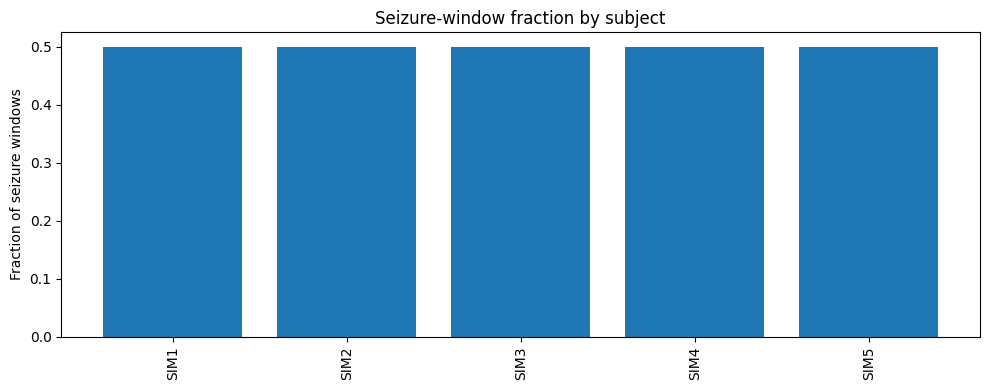

In [9]:
plt.figure(figsize=(10, 4))
plot_df = subject_balance_df.sort_values(SUBJECT_COLUMN)
plt.bar(plot_df[SUBJECT_COLUMN], plot_df["seizure_fraction"])
plt.xticks(rotation=90)
plt.ylabel("Fraction of seizure windows")
plt.title("Seizure-window fraction by subject")
plt.tight_layout()
plt.show()


## Choose the feature columns

We separate:
- **metadata columns**: subject ID, recording ID, label, timing info
- **feature columns**: the numeric values used by the classifier

If feature selection was run before, we can also load the selected feature lists and use the fold-specific subset for each held-out subject.


In [10]:
META_COLUMNS = {
    "subject_id",
    "recording_id",
    "fileName",
    "window_idx",
    "window_start_s",
    "window_end_s",
    "target",
    "label",
    "is_seizure_window",
    "crop_start_s",
    "crop_end_s",
    "fs",
    "n_channels",
}

feature_columns = [
    c for c in df.columns
    if c not in META_COLUMNS and pd.api.types.is_numeric_dtype(df[c])
]

print(f"Found {len(feature_columns)} numeric feature columns.")
feature_columns[:20]


Found 101 numeric feature columns.


['crop_duration_s',
 'line_length__ch01',
 'line_length__ch02',
 'line_length__ch03',
 'line_length__ch04',
 'line_length__ch05',
 'line_length__ch06',
 'line_length__ch07',
 'line_length__ch08',
 'line_length__ch09',
 'line_length__ch10',
 'line_length__ch11',
 'line_length__ch12',
 'line_length__ch13',
 'line_length__ch14',
 'line_length__ch15',
 'line_length__ch16',
 'line_length__ch17',
 'line_length__ch18',
 'line_length__ch19']

In [11]:
# Binary target encoding: seizure -> 1, non_seizure -> 0
label_map = {NEGATIVE_LABEL: 0, POSITIVE_LABEL: 1}
df["target_binary"] = df[TARGET_COLUMN].map(label_map).astype(int)

subjects = sorted(df[SUBJECT_COLUMN].unique())
print("Subjects included:", subjects)
print("Number of LOSO folds:", len(subjects))


Subjects included: ['SIM1', 'SIM2', 'SIM3', 'SIM4', 'SIM5']
Number of LOSO folds: 5


In [16]:
# Optional loading of fold-specific selected features
selected_features_by_fold = None

if USE_SELECTED_FEATURES:
    if FS_RUN_NAME is None:
        raise ValueError(
            "USE_SELECTED_FEATURES is True, but FS_RUN_NAME is None. "
            "Please set FS_RUN_NAME to the folder created by the feature-selection notebook."
        )
    fs_run_dir = FS_OUTPUT_DIR / FS_RUN_NAME
    selected_path = fs_run_dir / "selected_features_by_fold.csv"
    if not selected_path.exists():
        raise FileNotFoundError(f"Could not find selected feature file: {selected_path}")

    selected_df = pd.read_csv(selected_path)
    selected_features_by_fold = (
        selected_df.groupby("held_out_subject")["feature_name"]
        .apply(list)
        .to_dict()
    )

    print("Loaded fold-specific selected features from:")
    print(selected_path.resolve())
    print()
    print("Example fold selections:")
    ex_subject = sorted(selected_features_by_fold)[0]
    print(ex_subject, "->", selected_features_by_fold[ex_subject][:10])
else:
    print("Using all available feature columns.")


Loaded fold-specific selected features from:
C:\Users\rescic\PycharmProjects\cobrabox\examples\derived_ml_swec_short\feature_selection__rfe__mode-metric_stop__score-balanced_accuracy__base-logreg__auto-min-5__tol-0.001__step-1\selected_features_by_fold.csv

Example fold selections:
SIM1 -> ['is_seizure_window', 'amp_var__ch02', 'amp_var__ch04', 'max__ch02', 'max__ch07']


## Model choices

This notebook trains **one model at a time**, chosen with:

```python
MODEL_NAME = "logreg"
```

Available options:
- `"logreg"`
- `"linear_svm"`
- `"rbf_svm"`
- `"random_forest"`
- `"gradient_boosting"`
- `"xgboost"` if installed

### How to choose

A good beginner order is:
1. `"logreg"` — simple, fast, interpretable baseline
2. `"linear_svm"` — another linear model
3. `"random_forest"` — nonlinear tree ensemble with feature importance
4. `"rbf_svm"` — nonlinear SVM
5. `"xgboost"` — strong boosted-tree model

### Short explanation of each model

- **Logistic Regression (`"logreg"`)**
  A simple linear classifier. Good first choice for a baseline.
  Main parameters:
  - `C`: controls regularization strength. Smaller values mean stronger regularization and a simpler model.
  - `class_weight`: can be set to `"balanced"` to give more importance to the minority class.
  - `max_iter`: maximum number of optimization steps. Increase it if the model does not converge.


- **Linear SVM (`"linear_svm"`)**
  A linear classifier based on margin maximization.
  Main parameters:
  - `C`: controls the tradeoff between a wider margin and fewer training errors.
  - `class_weight`: can be set to `"balanced"` when classes are imbalanced.


- **RBF SVM (`"rbf_svm"`)**
  A nonlinear SVM that can model more complex boundaries.
  Main parameters:
  - `C`: controls regularization. Larger values fit the training data more closely.
  - `gamma`: controls how local the decision boundary is. Larger values make the model more sensitive to small local patterns.


- **Random Forest (`"random_forest"`)**
  A tree ensemble that handles nonlinear patterns well and gives feature importance.
  Main parameters:
  - `n_estimators`: number of trees in the forest. More trees usually improve stability but increase runtime.
  - `max_depth`: maximum depth of each tree. Smaller values can reduce overfitting.
  - `min_samples_split`: minimum number of samples needed to split a node. Larger values make trees more conservative.
  - `class_weight`: can be set to `"balanced"` for imbalanced classes.


- **Gradient Boosting (`"gradient_boosting"`)**
  A boosted-tree model that builds trees sequentially.
  Main parameters:
  - `n_estimators`: number of boosting stages. More stages can improve performance but may overfit.
  - `learning_rate`: controls how much each tree contributes. Smaller values are more conservative.
  - `max_depth`: controls the complexity of each individual tree.


- **XGBoost (`"xgboost"`)**
  A powerful boosted-tree model with more tuning options.
  Main parameters:
  - `n_estimators`: number of trees.
  - `learning_rate`: step size for boosting. Smaller values usually need more trees.
  - `max_depth`: controls tree complexity.
  - `subsample`: fraction of training samples used for each tree. Values below 1.0 can reduce overfitting.
  - `colsample_bytree`: fraction of features used for each tree. This can also reduce overfitting.
  - `scale_pos_weight`: gives more weight to the positive class and can help with class imbalance.

### Scaling

These models usually **need scaling**:
- `"logreg"`
- `"linear_svm"`
- `"rbf_svm"`

These usually **do not need scaling**:
- `"random_forest"`
- `"gradient_boosting"`
- `"xgboost"`

In this notebook, scaling is done inside each LOSO fold.

### Probabilities

All models are set up to return **seizure probabilities**. These are useful for:
- threshold tuning
- confidence analysis
- later HMM smoothing


In [17]:
def make_model(model_name: str, random_state: int = 42):
    if model_name == "logreg":
        return LogisticRegression(
            C=LOGREG_C,
            max_iter=2000,
            class_weight="balanced",
            solver="liblinear",
            random_state=random_state,
        )

    if model_name == "linear_svm":
        return SVC(
            kernel="linear",
            C=SVM_C,
            class_weight="balanced",
            probability=True,
            random_state=random_state,
        )

    if model_name == "rbf_svm":
        return SVC(
            kernel="rbf",
            C=SVM_C,
            gamma=SVM_GAMMA,
            class_weight="balanced",
            probability=True,
            random_state=random_state,
        )

    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=RF_N_ESTIMATORS,
            max_depth=RF_MAX_DEPTH,
            min_samples_leaf=RF_MIN_SAMPLES_LEAF,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        )

    if model_name == "gradient_boosting":
        return GradientBoostingClassifier(
            n_estimators=GB_N_ESTIMATORS,
            learning_rate=GB_LEARNING_RATE,
            max_depth=GB_MAX_DEPTH,
            random_state=random_state,
        )

    if model_name == "xgboost":
        if not HAS_XGBOOST:
            raise ImportError("xgboost is not installed in this environment.")
        return XGBClassifier(
            n_estimators=XGB_N_ESTIMATORS,
            max_depth=XGB_MAX_DEPTH,
            learning_rate=XGB_LEARNING_RATE,
            subsample=XGB_SUBSAMPLE,
            colsample_bytree=XGB_COLSAMPLE_BYTREE,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=random_state,
            n_jobs=-1,
        )

    raise ValueError(f"Unsupported MODEL_NAME: {model_name}")


In [29]:
def compute_binary_metrics(y_true, y_pred, y_prob):
    out = {}
    out["accuracy"] = accuracy_score(y_true, y_pred)
    out["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)
    out["precision"] = precision_score(y_true, y_pred, zero_division=0)
    out["recall"] = recall_score(y_true, y_pred, zero_division=0)
    out["f1"] = f1_score(y_true, y_pred, zero_division=0)

    # Some metrics need both classes to be present
    if len(np.unique(y_true)) == 2:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
        out["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out["tn"] = int(tn)
    out["fp"] = int(fp)
    out["fn"] = int(fn)
    out["tp"] = int(tp)
    return out


In [30]:
def choose_features_for_fold(held_out_subject: str):
    if not USE_SELECTED_FEATURES:
        return list(feature_columns)

    selected = selected_features_by_fold.get(held_out_subject, [])
    selected = [c for c in selected if c in feature_columns]
    if len(selected) == 0:
        raise ValueError(
            f"No valid selected features found for held-out subject {held_out_subject}. "
            "Check the feature-selection output."
        )
    return selected


## LOSO training loop

This is the main part of the notebook.

For each held-out subject:
1. select the training subjects
2. select the test subject
3. choose the feature subset for that fold
4. fit the scaler on the training data only
5. train the model
6. predict labels and probabilities on the held-out subject
7. save the fold results

This keeps the evaluation fair.


In [20]:
logo = LeaveOneGroupOut()

fold_rows = []
prediction_rows = []
feature_importance_rows = []

groups = df[SUBJECT_COLUMN].values
y_all = df["target_binary"].values

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(df, y_all, groups=groups), start=1):
    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    held_out_subject = str(test_df[SUBJECT_COLUMN].iloc[0])
    selected_features = choose_features_for_fold(held_out_subject)

    X_train = train_df[selected_features].copy()
    X_test = test_df[selected_features].copy()
    y_train = train_df["target_binary"].values
    y_test = test_df["target_binary"].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = make_model(MODEL_NAME, random_state=RANDOM_STATE)
    model.fit(X_train_scaled, y_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        raise ValueError(f"Model {MODEL_NAME} does not support predict_proba in this notebook.")

    y_pred = (y_prob >= POSITIVE_THRESHOLD).astype(int)

    metrics = compute_binary_metrics(y_test, y_pred, y_prob)
    metrics.update({
        "fold": fold_idx,
        "held_out_subject": held_out_subject,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "n_train_subjects": train_df[SUBJECT_COLUMN].nunique(),
        "n_test_subjects": test_df[SUBJECT_COLUMN].nunique(),
        "n_features_used": len(selected_features),
        "positive_rate_train": float(np.mean(y_train)),
        "positive_rate_test": float(np.mean(y_test)),
    })
    fold_rows.append(metrics)

    pred_df = pd.DataFrame({
        "fold": fold_idx,
        "held_out_subject": held_out_subject,
        SUBJECT_COLUMN: test_df[SUBJECT_COLUMN].values,
        RECORDING_COLUMN: test_df[RECORDING_COLUMN].values,
        WINDOW_INDEX_COLUMN: test_df[WINDOW_INDEX_COLUMN].values,
        "window_start_s": test_df["window_start_s"].values if "window_start_s" in test_df.columns else np.nan,
        "window_end_s": test_df["window_end_s"].values if "window_end_s" in test_df.columns else np.nan,
        "true_label_text": test_df[TARGET_COLUMN].values,
        "true_label": y_test,
        "pred_label": y_pred,
        "prob_non_seizure": 1.0 - y_prob,
        "prob_seizure": y_prob,
        "used_threshold": POSITIVE_THRESHOLD,
        "model_name": MODEL_NAME,
        "n_features_used": len(selected_features),
    })
    prediction_rows.append(pred_df)

    if hasattr(model, "coef_"):
        coef = np.ravel(model.coef_)
        fi_df = pd.DataFrame({
            "fold": fold_idx,
            "held_out_subject": held_out_subject,
            "feature_name": selected_features,
            "importance_type": "coefficient",
            "importance_value": coef,
            "importance_abs": np.abs(coef),
        })
        feature_importance_rows.append(fi_df)

    elif hasattr(model, "feature_importances_"):
        fi = np.ravel(model.feature_importances_)
        fi_df = pd.DataFrame({
            "fold": fold_idx,
            "held_out_subject": held_out_subject,
            "feature_name": selected_features,
            "importance_type": "feature_importance",
            "importance_value": fi,
            "importance_abs": np.abs(fi),
        })
        feature_importance_rows.append(fi_df)

    print(
        f"Fold {fold_idx:02d} | test subject={held_out_subject} | "
        f"features={len(selected_features)} | "
        f"balanced_acc={metrics['balanced_accuracy']:.4f} | "
        f"f1={metrics['f1']:.4f} | "
        f"roc_auc={metrics['roc_auc']:.4f}"
    )

fold_results_df = pd.DataFrame(fold_rows).sort_values("held_out_subject").reset_index(drop=True)
predictions_df = pd.concat(prediction_rows, ignore_index=True)

if feature_importance_rows:
    feature_importance_df = pd.concat(feature_importance_rows, ignore_index=True)
else:
    feature_importance_df = pd.DataFrame(columns=[
        "fold", "held_out_subject", "feature_name", "importance_type", "importance_value", "importance_abs"
    ])


Fold 01 | test subject=SIM1 | features=4 | balanced_acc=1.0000 | f1=1.0000 | roc_auc=1.0000
Fold 02 | test subject=SIM2 | features=4 | balanced_acc=1.0000 | f1=1.0000 | roc_auc=1.0000
Fold 03 | test subject=SIM3 | features=4 | balanced_acc=1.0000 | f1=1.0000 | roc_auc=1.0000
Fold 04 | test subject=SIM4 | features=4 | balanced_acc=1.0000 | f1=1.0000 | roc_auc=1.0000
Fold 05 | test subject=SIM5 | features=4 | balanced_acc=1.0000 | f1=1.0000 | roc_auc=1.0000


## Fold-level results

Each row below is one LOSO fold, which means one held-out participant.


In [21]:
fold_results_df


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,fold,held_out_subject,n_train_rows,n_test_rows,n_train_subjects,n_test_subjects,n_features_used,positive_rate_train,positive_rate_test
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,24,0,0,24,1,SIM1,192,48,4,1,4,0.5,0.5
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,24,0,0,24,2,SIM2,192,48,4,1,4,0.5,0.5
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,24,0,0,24,3,SIM3,192,48,4,1,4,0.5,0.5
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,24,0,0,24,4,SIM4,192,48,4,1,4,0.5,0.5
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,24,0,0,24,5,SIM5,192,48,4,1,4,0.5,0.5


In [22]:
metric_columns = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
summary_df = pd.DataFrame({
    "metric": metric_columns,
    "mean": [fold_results_df[c].mean() for c in metric_columns],
    "std": [fold_results_df[c].std() for c in metric_columns],
    "min": [fold_results_df[c].min() for c in metric_columns],
    "max": [fold_results_df[c].max() for c in metric_columns],
})
summary_df


,metric,mean,std,min,max
0,accuracy,1.0,0.000000e+00,1.0,1.0
1,balanced_accuracy,1.0,0.000000e+00,1.0,1.0
2,precision,1.0,0.000000e+00,1.0,1.0
3,recall,1.0,0.000000e+00,1.0,1.0
4,f1,1.0,0.000000e+00,1.0,1.0
5,roc_auc,1.0,0.000000e+00,1.0,1.0
6,pr_auc,1.0,1.241267e-16,1.0,1.0


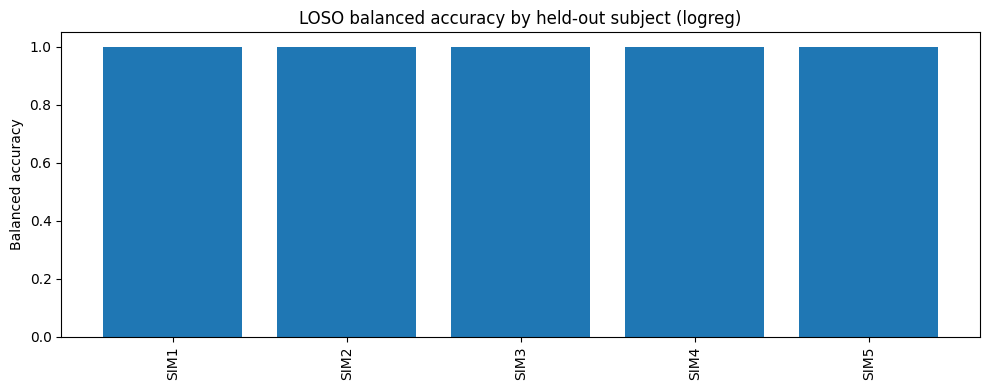

In [23]:
plt.figure(figsize=(10, 4))
plot_df = fold_results_df.sort_values("held_out_subject")
plt.bar(plot_df["held_out_subject"], plot_df["balanced_accuracy"])
plt.xticks(rotation=90)
plt.ylabel("Balanced accuracy")
plt.title(f"LOSO balanced accuracy by held-out subject ({MODEL_NAME})")
plt.tight_layout()
plt.show()


## Combined confusion matrix

This combines all held-out predictions across LOSO folds.
It gives a simple global view of:
- true negatives
- false positives
- false negatives
- true positives


In [24]:
cm = confusion_matrix(predictions_df["true_label"], predictions_df["pred_label"], labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["true_non_seizure", "true_seizure"],
    columns=["pred_non_seizure", "pred_seizure"]
)
cm_df


,pred_non_seizure,pred_seizure
true_non_seizure,120,0
true_seizure,0,120


In [25]:
print(classification_report(
    predictions_df["true_label"],
    predictions_df["pred_label"],
    target_names=[NEGATIVE_LABEL, POSITIVE_LABEL],
    zero_division=0,
))


              precision    recall  f1-score   support

 non_seizure       1.00      1.00      1.00       120
     seizure       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



## Feature importance overview

For models that support coefficients or feature importances, we collect them fold by fold.

This is useful for later explainability.


In [26]:
if not feature_importance_df.empty:
    feature_importance_summary_df = (
        feature_importance_df.groupby("feature_name")
        .agg(
            mean_importance=("importance_value", "mean"),
            mean_abs_importance=("importance_abs", "mean"),
            selected_in_folds=("held_out_subject", "count"),
        )
        .reset_index()
        .sort_values(["mean_abs_importance", "selected_in_folds"], ascending=[False, False])
        .reset_index(drop=True)
    )
    feature_importance_summary_df.head(25)
else:
    print("This model did not produce a feature-importance table in the current implementation.")
    feature_importance_summary_df = pd.DataFrame()


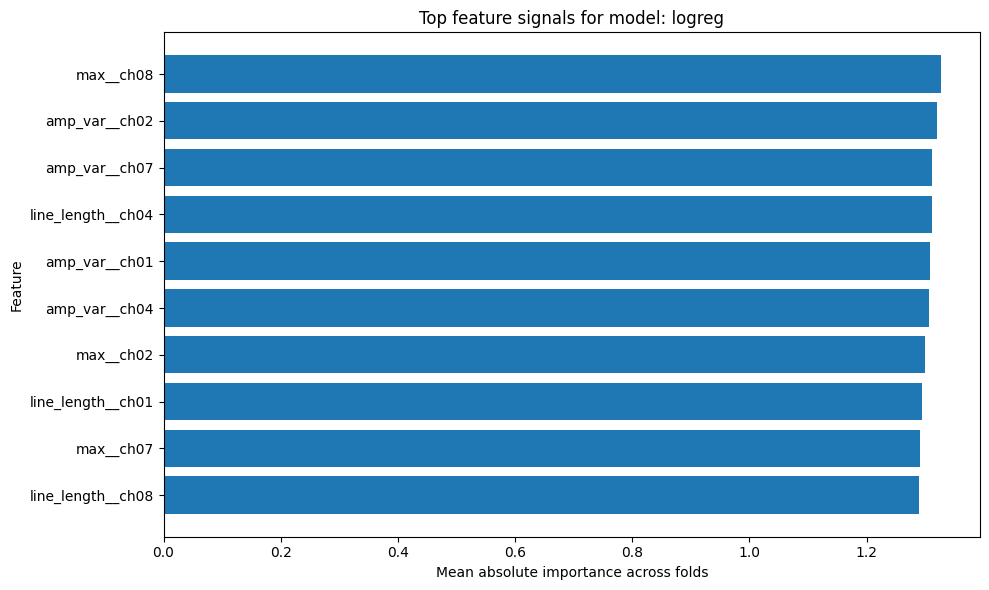

In [27]:
if not feature_importance_df.empty:
    top_imp = feature_importance_summary_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 6))
    plt.barh(top_imp["feature_name"], top_imp["mean_abs_importance"])
    plt.xlabel("Mean absolute importance across folds")
    plt.ylabel("Feature")
    plt.title(f"Top feature signals for model: {MODEL_NAME}")
    plt.tight_layout()
    plt.show()


## Save outputs

We save:
- fold-level metrics
- all window-level predictions
- probability outputs
- feature-importance tables
- model configuration summary

These saved files will be useful in the next notebook for:
- HMM smoothing
- explainability
- threshold experiments


In [28]:
feature_tag = "all_features"
if USE_SELECTED_FEATURES:
    feature_tag = FS_RUN_NAME.replace("feature_selection__", "selected__")

run_tag = f"model__{MODEL_NAME}__features-{feature_tag}__thr-{POSITIVE_THRESHOLD:.2f}"
run_dir = OUTPUT_DIR / run_tag
run_dir.mkdir(parents=True, exist_ok=True)

fold_results_df.to_csv(run_dir / "fold_results.csv", index=False)
summary_df.to_csv(run_dir / "metric_summary.csv", index=False)
predictions_df.to_csv(run_dir / "window_predictions.csv", index=False)
subject_balance_df.to_csv(run_dir / "subject_balance.csv", index=False)
overall_balance_df.to_csv(run_dir / "overall_balance.csv", index=False)

if not feature_importance_df.empty:
    feature_importance_df.to_csv(run_dir / "feature_importance_by_fold.csv", index=False)
    feature_importance_summary_df.to_csv(run_dir / "feature_importance_summary.csv", index=False)

config_lines = [
    f"MODEL_NAME = {MODEL_NAME}",
    f"USE_SELECTED_FEATURES = {USE_SELECTED_FEATURES}",
    f"FS_RUN_NAME = {FS_RUN_NAME}",
    f"POSITIVE_THRESHOLD = {POSITIVE_THRESHOLD}",
    f"N_SUBJECTS = {len(subjects)}",
    f"N_ROWS = {len(df)}",
    f"N_TOTAL_FEATURES = {len(feature_columns)}",
    f"MEAN_BALANCED_ACCURACY = {fold_results_df['balanced_accuracy'].mean():.6f}",
    f"MEAN_F1 = {fold_results_df['f1'].mean():.6f}",
    f"MEAN_ROC_AUC = {fold_results_df['roc_auc'].mean():.6f}",
]
(run_dir / "run_summary.txt").write_text("\n".join(config_lines))

print("Saved run directory:")
print(run_dir.resolve())
print()
print("Files:")
for p in sorted(run_dir.iterdir()):
    print("-", p.name)


Saved run directory:
C:\Users\rescic\PycharmProjects\cobrabox\examples\derived_ml_swec_short\model__logreg__features-__thr-0.50

Files:
- feature_importance_by_fold.csv
- feature_importance_summary.csv
- fold_results.csv
- metric_summary.csv
- overall_balance.csv
- run_summary.txt
- subject_balance.csv
- window_predictions.csv
